# DLRM for Movie Recommendation

## Objective

In this notebook, we implement **DLRM (Deep Learning Recommendation Model)**, the recommendation architecture introduced by Meta (Facebook AI).

DLRM is widely used in large-scale recommendation and advertising systems.

Unlike DeepFM, DLRM explicitly models feature interactions through a dedicated interaction layer.

The notebook covers:

1. Data preprocessing
2. Sparse and dense feature embeddings
3. Bottom MLP
4. Feature Interaction Layer
5. Top MLP
6. Model training
7. Model evaluation
8. Comparison with previous recommendation models

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (

    accuracy_score,

    roc_auc_score,

    roc_curve

)

import torch
import torch.nn as nn

from torch.utils.data import (

    Dataset,

    DataLoader

)

torch.manual_seed(42)

np.random.seed(42)

In [2]:
rating_columns = [

    "user_id",

    "movie_id",

    "rating",

    "timestamp"

]

ratings = pd.read_csv(

    "../data/u.data",

    sep="\t",

    names=rating_columns

)

ratings["user_id"] -= 1
ratings["movie_id"] -= 1

ratings.head()

,user_id,movie_id,rating,timestamp
0,195,241,3,881250949
1,185,301,3,891717742
2,21,376,1,878887116
3,243,50,2,880606923
4,165,345,1,886397596


In [3]:
user_columns = [

    "user_id",

    "age",

    "gender",

    "occupation",

    "zip_code"

]

users = pd.read_csv(

    "../data/u.user",

    sep="|",

    names=user_columns

)

users["user_id"] -= 1

users.head()

,user_id,age,gender,occupation,zip_code
0,0,24,M,technician,85711
1,1,53,F,other,94043
2,2,23,M,writer,32067
3,3,24,M,technician,43537
4,4,33,F,other,15213


In [4]:
movie_columns = [

    "movie_id",

    "title",

    "release_date",

    "video_release_date",

    "IMDb_URL"

]

genre_columns = [

    "unknown",

    "Action",

    "Adventure",

    "Animation",

    "Children",

    "Comedy",

    "Crime",

    "Documentary",

    "Drama",

    "Fantasy",

    "Film-Noir",

    "Horror",

    "Musical",

    "Mystery",

    "Romance",

    "Sci-Fi",

    "Thriller",

    "War",

    "Western"

]

movie_columns += genre_columns

movies = pd.read_csv(

    "../data/u.item",

    sep="|",

    encoding="latin-1",

    names=movie_columns

)

movies["movie_id"] -= 1

movies.head()

,movie_id,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,2,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,3,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [5]:
data = ratings.merge(

    users,

    on="user_id"

)

data = data.merge(

    movies,

    on="movie_id"

)

data.head()

,user_id,movie_id,rating,timestamp,age,gender,occupation,zip_code,title,release_date,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,195,241,3,881250949,49,M,writer,55105,Kolya (1996),24-Jan-1997,...,0,0,0,0,0,0,0,0,0,0
1,185,301,3,891717742,39,F,executive,00000,L.A. Confidential (1997),01-Jan-1997,...,0,1,0,0,1,0,0,1,0,0
2,21,376,1,878887116,25,M,writer,40206,Heavyweights (1994),01-Jan-1994,...,0,0,0,0,0,0,0,0,0,0
3,243,50,2,880606923,28,M,technician,80525,Legends of the Fall (1994),01-Jan-1994,...,0,0,0,0,0,1,0,0,1,1
4,165,345,1,886397596,47,M,educator,55113,Jackie Brown (1997),01-Jan-1997,...,0,0,0,0,0,0,0,0,0,0


In [6]:
data["label"] = (

    data["rating"] >= 4

).astype(np.float32)

data[["rating","label"]].head()

,rating,label
0,3,0.0
1,3,0.0
2,1,0.0
3,2,0.0
4,1,0.0


In [7]:
train_df, test_df = train_test_split(

    data,

    test_size=0.2,

    random_state=42,

    stratify=data["label"]

)

In [8]:
gender_encoder = LabelEncoder()

occupation_encoder = LabelEncoder()

train_df["gender_idx"] = gender_encoder.fit_transform(

    train_df["gender"]

)

test_df["gender_idx"] = gender_encoder.transform(

    test_df["gender"]

)

train_df["occupation_idx"] = occupation_encoder.fit_transform(

    train_df["occupation"]

)

test_df["occupation_idx"] = occupation_encoder.transform(

    test_df["occupation"]

)

max_age = train_df["age"].max()

train_df["age"] /= max_age

test_df["age"] /= max_age

In [9]:
NUM_USERS = data["user_id"].nunique()

NUM_MOVIES = data["movie_id"].nunique()

NUM_GENDERS = len(

    gender_encoder.classes_

)

NUM_OCCUPATIONS = len(

    occupation_encoder.classes_

)

print(NUM_USERS)

print(NUM_MOVIES)

print(NUM_GENDERS)

print(NUM_OCCUPATIONS)

943
1682
2
21


In [10]:
class DLRMDataset(Dataset):

    def __init__(self, dataframe):

        self.user = torch.LongTensor(
            dataframe["user_id"].values
        )

        self.movie = torch.LongTensor(
            dataframe["movie_id"].values
        )

        self.gender = torch.LongTensor(
            dataframe["gender_idx"].values
        )

        self.occupation = torch.LongTensor(
            dataframe["occupation_idx"].values
        )

        # Dense features
        self.dense = torch.FloatTensor(

            np.column_stack(

                [

                    dataframe["age"].values,

                    dataframe[genre_columns].values

                ]

            )

        )

        self.labels = torch.FloatTensor(
            dataframe["label"].values
        )

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        return (

            self.user[idx],

            self.movie[idx],

            self.gender[idx],

            self.occupation[idx],

            self.dense[idx],

            self.labels[idx]

        )

In [11]:
train_dataset = DLRMDataset(train_df)

test_dataset = DLRMDataset(test_df)
train_loader = DataLoader(

    train_dataset,

    batch_size=512,

    shuffle=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=512,

    shuffle=False

)

In [12]:
batch = next(iter(train_loader))

for tensor in batch:

    print(tensor.shape)

torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([512, 20])
torch.Size([512])


In [13]:
class SparseEmbeddingLayer(nn.Module):

    def __init__(

        self,

        num_users,

        num_movies,

        num_genders,

        num_occupations,

        embedding_dim=16

    ):

        super().__init__()

        self.user_embedding = nn.Embedding(
            num_users,
            embedding_dim
        )

        self.movie_embedding = nn.Embedding(
            num_movies,
            embedding_dim
        )

        self.gender_embedding = nn.Embedding(
            num_genders,
            embedding_dim
        )

        self.occupation_embedding = nn.Embedding(
            num_occupations,
            embedding_dim
        )

    def forward(

        self,

        user,

        movie,

        gender,

        occupation

    ):

        return [

            self.user_embedding(user),

            self.movie_embedding(movie),

            self.gender_embedding(gender),

            self.occupation_embedding(occupation)

        ]

In [14]:
embedding_layer = SparseEmbeddingLayer(

    NUM_USERS,

    NUM_MOVIES,

    NUM_GENDERS,

    NUM_OCCUPATIONS

)

batch = next(iter(train_loader))

embeddings = embedding_layer(

    batch[0],

    batch[1],

    batch[2],

    batch[3]

)

for e in embeddings:

    print(e.shape)

torch.Size([512, 16])
torch.Size([512, 16])
torch.Size([512, 16])
torch.Size([512, 16])


In [15]:
class BottomMLP(nn.Module):

    def __init__(

        self,

        input_dim=20,

        embedding_dim=16

    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim,64),

            nn.ReLU(),

            nn.Linear(64,32),

            nn.ReLU(),

            nn.Linear(32,embedding_dim)

        )

    def forward(

        self,

        dense_features

    ):

        return self.network(

            dense_features

        )

In [16]:
bottom = BottomMLP()

dense_embedding = bottom(

    batch[4]

)

print(

    dense_embedding.shape

)

torch.Size([512, 16])


In [17]:
features = embeddings + [

    dense_embedding

]

for f in features:

    print(

        f.shape

    )

torch.Size([512, 16])
torch.Size([512, 16])
torch.Size([512, 16])
torch.Size([512, 16])
torch.Size([512, 16])


In [18]:
class FeatureInteraction(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, feature_embeddings):

        # feature_embeddings is a list of tensors
        # each tensor has shape (batch_size, embedding_dim)

        X = torch.stack(

            feature_embeddings,

            dim=1

        )

        # (batch_size, num_features, embedding_dim)

        interaction_matrix = torch.bmm(

            X,

            X.transpose(1, 2)

        )

        return interaction_matrix

In [19]:
interaction_layer = FeatureInteraction()

interaction_matrix = interaction_layer(

    features

)

print(interaction_matrix.shape)

torch.Size([512, 5, 5])


In [20]:
sample = interaction_matrix[0]

print(sample)

tensor([[ 7.2026, -1.2879,  1.3461, -5.5436,  0.0476],
        [-1.2879,  8.8944, -3.4139, -3.3590,  0.4300],
        [ 1.3461, -3.4139, 18.8446,  1.7243, -0.8378],
        [-5.5436, -3.3590,  1.7243, 15.2376, -0.3327],
        [ 0.0476,  0.4300, -0.8378, -0.3327,  0.1644]],
       grad_fn=<SelectBackward0>)


In [21]:
interaction_vector = interaction_matrix.reshape(

    interaction_matrix.size(0),

    -1

)

print(interaction_vector.shape)

torch.Size([512, 25])


In [22]:
class TopMLP(nn.Module):

    def __init__(

        self,

        interaction_dim,

        embedding_dim=16

    ):

        super().__init__()

        input_dim = interaction_dim + embedding_dim

        self.network = nn.Sequential(

            nn.Linear(input_dim, 128),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(128, 64),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(64, 1)

        )

    def forward(

        self,

        interaction_vector,

        dense_embedding

    ):

        x = torch.cat(

            [

                interaction_vector,

                dense_embedding

            ],

            dim=1

        )

        return self.network(x).squeeze()

In [23]:
top_mlp = TopMLP(

    interaction_dim=25,

    embedding_dim=16

)

output = top_mlp(

    interaction_vector,

    dense_embedding

)

print(output.shape)

torch.Size([512])


In [24]:
class DLRM(nn.Module):

    def __init__(

        self,

        num_users,

        num_movies,

        num_genders,

        num_occupations,

        embedding_dim=16

    ):

        super().__init__()

        self.embedding_layer = SparseEmbeddingLayer(

            num_users,

            num_movies,

            num_genders,

            num_occupations,

            embedding_dim

        )

        self.bottom_mlp = BottomMLP(

            input_dim=20,

            embedding_dim=embedding_dim

        )

        self.interaction = FeatureInteraction()

        self.top_mlp = TopMLP(

            interaction_dim=25,

            embedding_dim=embedding_dim

        )

    def forward(

        self,

        user,

        movie,

        gender,

        occupation,

        dense

    ):

        sparse_embeddings = self.embedding_layer(

            user,

            movie,

            gender,

            occupation

        )

        dense_embedding = self.bottom_mlp(

            dense

        )

        features = sparse_embeddings + [

            dense_embedding

        ]

        interaction_matrix = self.interaction(

            features

        )

        interaction_vector = interaction_matrix.reshape(

            interaction_matrix.size(0),

            -1

        )

        output = self.top_mlp(

            interaction_vector,

            dense_embedding

        )

        return output

In [25]:
model = DLRM(

    NUM_USERS,

    NUM_MOVIES,

    NUM_GENDERS,

    NUM_OCCUPATIONS,

    embedding_dim=16

)

model

DLRM(
  (embedding_layer): SparseEmbeddingLayer(
    (user_embedding): Embedding(943, 16)
    (movie_embedding): Embedding(1682, 16)
    (gender_embedding): Embedding(2, 16)
    (occupation_embedding): Embedding(21, 16)
  )
  (bottom_mlp): BottomMLP(
    (network): Sequential(
      (0): Linear(in_features=20, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=32, bias=True)
      (3): ReLU()
      (4): Linear(in_features=32, out_features=16, bias=True)
    )
  )
  (interaction): FeatureInteraction()
  (top_mlp): TopMLP(
    (network): Sequential(
      (0): Linear(in_features=41, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.2, inplace=False)
      (6): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)

In [26]:
batch = next(

    iter(train_loader)

)

outputs = model(

    batch[0],

    batch[1],

    batch[2],

    batch[3],

    batch[4]

)

print(outputs.shape)

torch.Size([512])


In [27]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=1e-3

)

In [28]:
batch = next(

    iter(train_loader)

)

optimizer.zero_grad()

outputs = model(

    batch[0],

    batch[1],

    batch[2],

    batch[3],

    batch[4]

)

loss = criterion(

    outputs,

    batch[5]

)

loss.backward()

optimizer.step()

print(

    "Loss:",

    loss.item()

)

Loss: 0.8181852698326111


In [29]:
def train_model(

    model,

    train_loader,

    criterion,

    optimizer,

    epochs=20

):

    print("Training DLRM...")

    history = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        for (

            user,

            movie,

            gender,

            occupation,

            dense,

            labels

        ) in train_loader:

            optimizer.zero_grad()

            outputs = model(

                user,

                movie,

                gender,

                occupation,

                dense

            )

            loss = criterion(

                outputs,

                labels

            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        history.append(epoch_loss)

        print(

            f"Epoch {epoch+1:2d}/{epochs} | Loss = {epoch_loss:.4f}"

        )

    return history

In [30]:
history = train_model(

    model,

    train_loader,

    criterion,

    optimizer,

    epochs=20

)

Training DLRM...
Epoch  1/20 | Loss = 0.6933
Epoch  2/20 | Loss = 0.6689
Epoch  3/20 | Loss = 0.6521
Epoch  4/20 | Loss = 0.6344
Epoch  5/20 | Loss = 0.6191
Epoch  6/20 | Loss = 0.6052
Epoch  7/20 | Loss = 0.5930
Epoch  8/20 | Loss = 0.5826
Epoch  9/20 | Loss = 0.5737
Epoch 10/20 | Loss = 0.5669
Epoch 11/20 | Loss = 0.5612
Epoch 12/20 | Loss = 0.5556
Epoch 13/20 | Loss = 0.5517
Epoch 14/20 | Loss = 0.5469
Epoch 15/20 | Loss = 0.5437
Epoch 16/20 | Loss = 0.5415
Epoch 17/20 | Loss = 0.5390
Epoch 18/20 | Loss = 0.5364
Epoch 19/20 | Loss = 0.5337
Epoch 20/20 | Loss = 0.5307


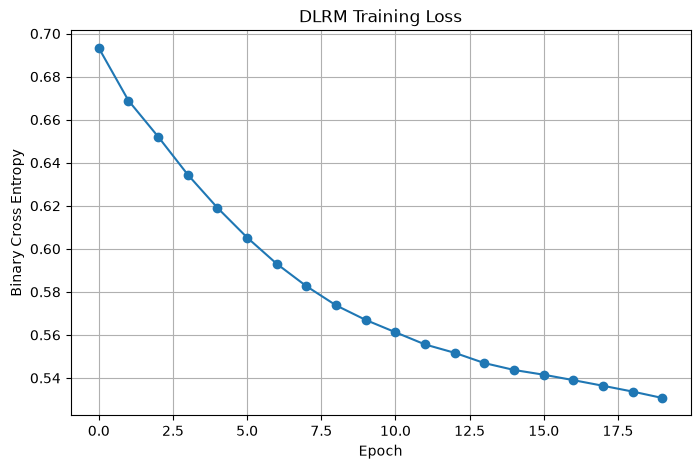

In [31]:
plt.figure(figsize=(8,5))

plt.plot(

    history,

    marker="o"

)

plt.title("DLRM Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Binary Cross Entropy")

plt.grid(True)

plt.show()

In [32]:
def evaluate_model(

    model,

    test_loader

):

    model.eval()

    probabilities = []

    predictions = []

    labels = []

    with torch.no_grad():

        for (

            user,

            movie,

            gender,

            occupation,

            dense,

            target

        ) in test_loader:

            logits = model(

                user,

                movie,

                gender,

                occupation,

                dense

            )

            probs = torch.sigmoid(

                logits

            )

            preds = (

                probs >= 0.5

            ).float()

            probabilities.extend(

                probs.cpu().numpy()

            )

            predictions.extend(

                preds.cpu().numpy()

            )

            labels.extend(

                target.cpu().numpy()

            )

    accuracy = accuracy_score(

        labels,

        predictions

    )

    auc = roc_auc_score(

        labels,

        probabilities

    )

    return (

        accuracy,

        auc,

        np.array(probabilities),

        np.array(predictions),

        np.array(labels)

    )

In [33]:
accuracy, auc, probabilities, predictions, labels = evaluate_model(

    model,

    test_loader

)

print(

    f"Accuracy : {accuracy:.4f}"

)

print(

    f"AUC : {auc:.4f}"

)

Accuracy : 0.7084
AUC : 0.7739


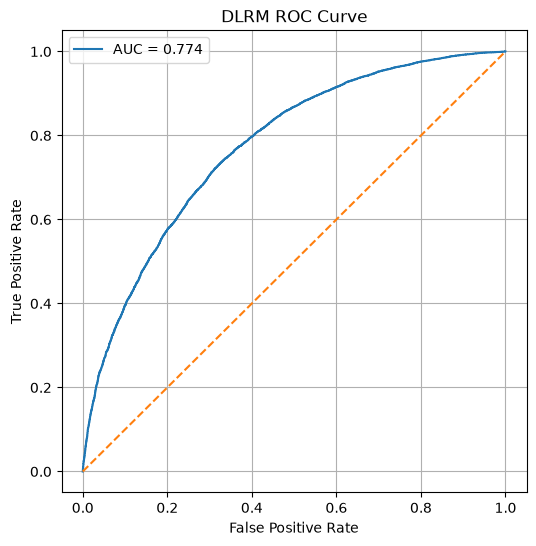

In [34]:
fpr, tpr, _ = roc_curve(

    labels,

    probabilities

)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("DLRM ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [35]:
prediction_df = test_df.copy()

prediction_df["probability"] = probabilities

prediction_df["prediction"] = predictions

prediction_df.head()

,user_id,movie_id,rating,timestamp,age,gender,occupation,zip_code,title,release_date,...,Romance,Sci-Fi,Thriller,War,Western,label,gender_idx,occupation_idx,probability,prediction
70309,406,152,4,875042569,0.397260,M,engineer,03261,"Fish Called Wanda, A (1988)",01-Jan-1988,...,0,0,0,0,0,1.0,1,4,0.557343,1.0
14503,241,290,3,879740593,0.452055,M,educator,31404,Absolute Power (1997),14-Feb-1997,...,0,0,1,0,0,0.0,1,3,0.861601,1.0
22229,329,237,5,876546323,0.479452,F,educator,33884,Raising Arizona (1987),01-Jan-1987,...,0,0,0,0,0,1.0,0,3,0.948011,1.0
34450,403,753,3,883790218,0.397260,F,programmer,55108,Red Corner (1997),01-Jan-1997,...,0,0,1,0,0,0.0,0,14,0.225410,0.0
28502,325,43,1,879875852,0.561644,M,administrator,15235,Dolores Claiborne (1994),01-Jan-1994,...,0,0,1,0,0,0.0,1,0,0.221412,0.0


In [36]:
def precision_at_k(

    prediction_df,

    k=10

):

    precisions = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        precisions.append(

            top_k["label"].mean()

        )

    return np.mean(

        precisions

    )

In [37]:
def recall_at_k(

    prediction_df,

    k=10

):

    recalls = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        relevant = group["label"].sum()

        if relevant == 0:

            continue

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits = top_k["label"].sum()

        recalls.append(

            hits / relevant

        )

    return np.mean(

        recalls

    )

In [38]:
def hit_rate_at_k(

    prediction_df,

    k=10

):

    hits = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits.append(

            top_k["label"].sum() > 0

        )

    return np.mean(

        hits

    )

In [39]:
precision = precision_at_k(

    prediction_df,

    k=10

)

recall = recall_at_k(

    prediction_df,

    k=10

)

hitrate = hit_rate_at_k(

    prediction_df,

    k=10

)

metrics = pd.DataFrame(

    {

        "Metric":[

            "Accuracy",

            "AUC",

            "Precision@10",

            "Recall@10",

            "HitRate@10"

        ],

        "Value":[

            accuracy,

            auc,

            precision,

            recall,

            hitrate

        ]

    }

)

metrics

,Metric,Value
0,Accuracy,0.708350
1,AUC,0.773892
2,Precision@10,0.663191
3,Recall@10,0.726438
4,HitRate@10,0.977731


In [40]:
prediction_df[[

    "user_id",

    "movie_id",

    "label",

    "probability",

    "prediction"

]].head(20)

,user_id,movie_id,label,probability,prediction
70309,406,152,1.0,0.557343,1.0
14503,241,290,0.0,0.861601,1.0
22229,329,237,1.0,0.948011,1.0
34450,403,753,0.0,0.225410,0.0
28502,325,43,0.0,0.221412,0.0
78501,758,983,0.0,0.389378,0.0
62828,842,541,0.0,0.029145,0.0
85723,549,14,1.0,0.651014,1.0
99463,775,216,1.0,0.213621,0.0
95612,641,451,0.0,0.390936,0.0


In [41]:
comparison = pd.DataFrame(

    {

        "Model":[

            "Ranking MLP",

            "Wide & Deep",

            "DeepFM",

            "DLRM"

        ],

        "Accuracy":[

            0.8400,

            0.8334,

            0.6816,

            accuracy

        ],

        "AUC":[

            0.7862,

            0.7763,

            0.7386,

            auc

        ],

        "Precision@10":[

            0.9102,

            0.8831,

            0.6500,

            precision

        ],

        "Recall@10":[

            0.5092,

            0.6886,

            0.7169,

            recall

        ],

        "HitRate@10":[

            0.9978,

            0.9957,

            0.9767,

            hitrate

        ]

    }

)

comparison

,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.84000,0.786200,0.910200,0.509200,0.997800
1,Wide & Deep,0.83340,0.776300,0.883100,0.688600,0.995700
2,DeepFM,0.68160,0.738600,0.650000,0.716900,0.976700
3,DLRM,0.70835,0.773892,0.663191,0.726438,0.977731


In [42]:
print("Best Accuracy")

display(

    comparison.sort_values(

        "Accuracy",

        ascending=False

    )

)

print("Best AUC")

display(

    comparison.sort_values(

        "AUC",

        ascending=False

    )

)

print("Best Precision@10")

display(

    comparison.sort_values(

        "Precision@10",

        ascending=False

    )

)

print("Best Recall@10")

display(

    comparison.sort_values(

        "Recall@10",

        ascending=False

    )

)

print("Best HitRate@10")

display(

    comparison.sort_values(

        "HitRate@10",

        ascending=False

    )

)

Best Accuracy


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.84000,0.786200,0.910200,0.509200,0.997800
1,Wide & Deep,0.83340,0.776300,0.883100,0.688600,0.995700
3,DLRM,0.70835,0.773892,0.663191,0.726438,0.977731
2,DeepFM,0.68160,0.738600,0.650000,0.716900,0.976700


Best AUC


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.84000,0.786200,0.910200,0.509200,0.997800
1,Wide & Deep,0.83340,0.776300,0.883100,0.688600,0.995700
3,DLRM,0.70835,0.773892,0.663191,0.726438,0.977731
2,DeepFM,0.68160,0.738600,0.650000,0.716900,0.976700


Best Precision@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.84000,0.786200,0.910200,0.509200,0.997800
1,Wide & Deep,0.83340,0.776300,0.883100,0.688600,0.995700
3,DLRM,0.70835,0.773892,0.663191,0.726438,0.977731
2,DeepFM,0.68160,0.738600,0.650000,0.716900,0.976700


Best Recall@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
3,DLRM,0.70835,0.773892,0.663191,0.726438,0.977731
2,DeepFM,0.68160,0.738600,0.650000,0.716900,0.976700
1,Wide & Deep,0.83340,0.776300,0.883100,0.688600,0.995700
0,Ranking MLP,0.84000,0.786200,0.910200,0.509200,0.997800


Best HitRate@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.84000,0.786200,0.910200,0.509200,0.997800
1,Wide & Deep,0.83340,0.776300,0.883100,0.688600,0.995700
3,DLRM,0.70835,0.773892,0.663191,0.726438,0.977731
2,DeepFM,0.68160,0.738600,0.650000,0.716900,0.976700


# Conclusion

In this notebook, we implemented **Deep Learning Recommendation Model (DLRM)**, Meta's industrial recommendation architecture.

Key observations:

- Sparse categorical features were represented using embedding tables.
- Dense numerical features were processed through a Bottom MLP.
- Feature interactions were explicitly computed using a pairwise interaction layer.
- The interaction outputs were combined with the dense representation and passed to a Top MLP for prediction.

Compared to previous models:

- Ranking MLP learns implicit feature interactions.
- Wide & Deep combines manually engineered wide features with deep representations.
- DeepFM automatically learns low-order feature interactions using a Factorization Machine.
- DLRM explicitly models pairwise feature interactions and is designed for production-scale recommendation systems.

DLRM is one of the most influential recommendation architectures and has been widely adopted in industrial recommender and advertising systems.